In [1]:
import pandas as pd
from pathlib import Path

folder = Path("DAM")


files = sorted(folder.glob("2024*_EL-DAM_Results_EN_v01.xlsx"))

all_data = []

for file in files:
    df = pd.read_excel(file, sheet_name="EL-DAM_Results")

    df["DELIVERY_MTU"] = pd.to_datetime(df["DELIVERY_MTU"], errors="coerce")
    df = df[df["DELIVERY_MTU"].dt.year == 2024]

    df["MONTH"] = df["DELIVERY_MTU"].dt.to_period("M").astype(str)

    all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

/Users/petrinakorfiati/opt/anaconda3/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/petrinakorfiati/opt/anaconda3/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/petrinakorfiati/opt/anaconda3/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/petrinakorfiati/opt/anaconda3/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/petrinakorfia

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
data

,TARGET,BIDDING_ZONE_DESCR,SIDE_DESCR,DDAY,ASSET_DESCR,CLASSIFICATION,DELIVERY_MTU,DELIVERY_DURATION,SORT,MCP,TOTAL_TRADES,PUB_TIME,VER,MONTH
0,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 00:00:00,60,1,107.09,91.0,2023-12-31 14:22:19,1,2024-01
1,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 01:00:00,60,2,104.00,93.0,2023-12-31 14:22:19,1,2024-01
2,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 02:00:00,60,3,100.00,40.0,2023-12-31 14:22:19,1,2024-01
3,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 03:00:00,60,4,85.66,41.0,2023-12-31 14:22:19,1,2024-01
4,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 08:00:00,60,9,65.00,9.0,2023-12-31 14:22:19,1,2024-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156495,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 19:00:00,60,20,178.88,75.0,2024-12-30 14:21:04,1,2024-12
156496,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 20:00:00,60,21,164.94,75.0,2024-12-30 14:21:04,1,2024-12
156497,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 21:00:00,60,22,150.00,75.0,2024-12-30 14:21:04,1,2024-12
156498,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 22:00:00,60,23,122.04,75.0,2024-12-30 14:21:04,1,2024-12


In [7]:
#Check hours of the day
data['SORT'].unique()

array([ 1,  2,  3,  4,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24,  5,  6,  7,  8, 25], dtype=int64)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156500 entries, 0 to 156499
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   TARGET              156500 non-null  object        
 1   BIDDING_ZONE_DESCR  156500 non-null  object        
 2   SIDE_DESCR          156500 non-null  object        
 3   DDAY                156500 non-null  int64         
 4   ASSET_DESCR         156500 non-null  object        
 5   CLASSIFICATION      156500 non-null  object        
 6   DELIVERY_MTU        156500 non-null  datetime64[ns]
 7   DELIVERY_DURATION   156500 non-null  int64         
 8   SORT                156500 non-null  int64         
 9   MCP                 156500 non-null  float64       
 10  TOTAL_TRADES        156500 non-null  float64       
 11  PUB_TIME            156500 non-null  object        
 12  VER                 156500 non-null  int64         
 13  MONTH               156500 no

In [9]:
# Rename the column of SORT to HOUR

data.rename(columns = {'SORT':'HOUR'},inplace=True)

In [10]:
data

,TARGET,BIDDING_ZONE_DESCR,SIDE_DESCR,DDAY,ASSET_DESCR,CLASSIFICATION,DELIVERY_MTU,DELIVERY_DURATION,HOUR,MCP,TOTAL_TRADES,PUB_TIME,VER,MONTH
0,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 00:00:00,60,1,107.09,91.0,2023-12-31 14:22:19,1,2024-01
1,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 01:00:00,60,2,104.00,93.0,2023-12-31 14:22:19,1,2024-01
2,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 02:00:00,60,3,100.00,40.0,2023-12-31 14:22:19,1,2024-01
3,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 03:00:00,60,4,85.66,41.0,2023-12-31 14:22:19,1,2024-01
4,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 08:00:00,60,9,65.00,9.0,2023-12-31 14:22:19,1,2024-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156495,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 19:00:00,60,20,178.88,75.0,2024-12-30 14:21:04,1,2024-12
156496,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 20:00:00,60,21,164.94,75.0,2024-12-30 14:21:04,1,2024-12
156497,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 21:00:00,60,22,150.00,75.0,2024-12-30 14:21:04,1,2024-12
156498,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 22:00:00,60,23,122.04,75.0,2024-12-30 14:21:04,1,2024-12


In [11]:
data["MONTH"] = pd.to_datetime(data["DELIVERY_MTU"]).dt.month

In [12]:
data

,TARGET,BIDDING_ZONE_DESCR,SIDE_DESCR,DDAY,ASSET_DESCR,CLASSIFICATION,DELIVERY_MTU,DELIVERY_DURATION,HOUR,MCP,TOTAL_TRADES,PUB_TIME,VER,MONTH
0,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 00:00:00,60,1,107.09,91.0,2023-12-31 14:22:19,1,1
1,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 01:00:00,60,2,104.00,93.0,2023-12-31 14:22:19,1,1
2,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 02:00:00,60,3,100.00,40.0,2023-12-31 14:22:19,1,1
3,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 03:00:00,60,4,85.66,41.0,2023-12-31 14:22:19,1,1
4,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 08:00:00,60,9,65.00,9.0,2023-12-31 14:22:19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156495,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 19:00:00,60,20,178.88,75.0,2024-12-30 14:21:04,1,12
156496,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 20:00:00,60,21,164.94,75.0,2024-12-30 14:21:04,1,12
156497,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 21:00:00,60,22,150.00,75.0,2024-12-30 14:21:04,1,12
156498,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 22:00:00,60,23,122.04,75.0,2024-12-30 14:21:04,1,12


In [13]:
#agg per hour for MCP for all year

mcp_per_hour = data.groupby('HOUR')['MCP'].agg(mean_mcp="mean",
          min_mcp="min",
          max_mcp="max",
          count_trades="count",
          std_mcp="std").reset_index()

In [14]:
mcp_per_hour

,HOUR,mean_mcp,min_mcp,max_mcp,count_trades,std_mcp
0,1,92.252343,3.00,180.47,6521,25.586433
1,2,88.289715,0.04,183.92,6312,23.915332
2,3,84.063199,1.64,165.92,6299,22.866909
3,4,82.084033,0.99,151.87,6291,22.320834
4,5,83.138424,4.40,135.39,6369,20.530947
5,6,90.978021,25.44,182.97,6507,20.429775
6,7,106.608645,9.92,200.94,6546,28.786701
7,8,113.991704,0.10,422.50,6427,47.038205
8,9,100.852544,-0.07,404.09,6474,43.892338
9,10,79.193462,-1.02,215.00,6539,37.026770


In [15]:
mcp_per_hour1 = mcp_per_hour.iloc[:-1]

In [16]:
#Delete the 25th hour

mcp_per_hour1

,HOUR,mean_mcp,min_mcp,max_mcp,count_trades,std_mcp
0,1,92.252343,3.00,180.47,6521,25.586433
1,2,88.289715,0.04,183.92,6312,23.915332
2,3,84.063199,1.64,165.92,6299,22.866909
3,4,82.084033,0.99,151.87,6291,22.320834
4,5,83.138424,4.40,135.39,6369,20.530947
5,6,90.978021,25.44,182.97,6507,20.429775
6,7,106.608645,9.92,200.94,6546,28.786701
7,8,113.991704,0.10,422.50,6427,47.038205
8,9,100.852544,-0.07,404.09,6474,43.892338
9,10,79.193462,-1.02,215.00,6539,37.026770


In [17]:
#agg per month per hour for MCP for all year

mcp_per_hour_per_month = (
    data.groupby(["MONTH", "HOUR"])["MCP"]
      .agg(
          mean_mcp="mean",
          min_mcp="min",
          max_mcp="max",
          count_trades="count"
      )
      .reset_index())

In [18]:
mcp_per_hour_per_month

,MONTH,HOUR,mean_mcp,min_mcp,max_mcp,count_trades
0,1,1,80.325000,49.97,107.51,528
1,1,2,78.820294,47.26,106.53,510
2,1,3,72.650781,40.00,104.81,512
3,1,4,67.716458,35.20,103.07,511
4,1,5,72.579432,49.31,106.00,511
...,...,...,...,...,...,...
284,12,20,182.052265,114.66,543.86,574
285,12,21,156.443380,113.21,293.08,574
286,12,22,135.481158,95.16,169.88,570
287,12,23,123.417707,73.76,150.00,567


In [19]:
pivot_mcp_mean = mcp_per_hour_per_month.pivot(
                    index='MONTH',
                    columns="HOUR",
                    values='mean_mcp')

In [20]:
pivot_mcp_mean

HOUR,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
MONTH,,,,,,,,,,,,,,,,,,,,,
1,80.325000,78.820294,72.650781,67.716458,72.579432,86.468708,100.607030,108.049559,109.320557,94.940429,...,101.959751,110.616116,119.815442,117.576388,112.107932,105.057754,97.075350,93.596788,85.943090,NaN
2,67.354204,66.601223,61.186796,60.791352,63.906715,73.143280,84.973252,88.176285,81.623366,72.026718,...,75.857717,83.167305,94.678451,100.767842,91.694773,87.061285,82.113616,79.326600,72.579528,NaN
3,67.816273,68.371216,67.100269,67.215515,67.009271,71.901442,77.812408,75.064879,65.658887,49.848198,...,58.108132,73.891966,88.143538,102.445664,102.676453,88.641657,79.424551,75.903947,71.058624,NaN
4,68.230113,65.355720,62.994732,62.415079,65.483116,71.289695,84.672985,78.845524,62.035541,47.054436,...,31.834612,42.503383,65.920352,80.809683,102.044368,101.921808,84.137228,79.351689,72.536705,NaN
5,83.306272,80.050514,77.411457,77.189920,79.554365,84.261711,93.749736,97.816630,79.212450,65.112463,...,56.496660,68.442108,82.660371,100.376072,127.386266,147.832756,122.286861,96.307962,88.810262,NaN
6,99.758252,94.621423,90.578563,89.853340,86.551519,90.493163,101.016319,105.798874,89.441881,69.416616,...,78.387308,92.531520,95.122456,123.699941,179.068845,209.496706,174.320642,126.386608,103.957327,NaN
7,123.977299,114.018596,104.614862,99.980261,95.648856,99.136569,108.074797,104.893067,95.395362,79.859718,...,96.830406,112.790282,125.963590,217.614646,334.509190,380.970811,288.322504,173.032516,139.824692,NaN
8,122.129721,115.413280,111.458952,108.210660,105.848521,110.519200,123.202809,123.227815,106.708766,89.522850,...,106.216333,125.206014,153.212904,217.651252,295.807632,292.849655,183.559983,137.492066,119.821465,NaN
9,96.787582,94.965824,91.907617,89.824492,91.000554,97.531227,126.568000,137.593071,119.044923,84.645899,...,74.843535,106.297181,152.988000,205.679758,317.436959,191.690244,137.186159,114.414539,103.738956,NaN


In [21]:
#Delete Column 25

pivot_mcp_mean = pivot_mcp_mean.drop(columns=[25])

In [22]:
pivot_mcp_mean

HOUR,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
MONTH,,,,,,,,,,,,,,,,,,,,,
1,80.325000,78.820294,72.650781,67.716458,72.579432,86.468708,100.607030,108.049559,109.320557,94.940429,...,91.230806,101.959751,110.616116,119.815442,117.576388,112.107932,105.057754,97.075350,93.596788,85.943090
2,67.354204,66.601223,61.186796,60.791352,63.906715,73.143280,84.973252,88.176285,81.623366,72.026718,...,63.325581,75.857717,83.167305,94.678451,100.767842,91.694773,87.061285,82.113616,79.326600,72.579528
3,67.816273,68.371216,67.100269,67.215515,67.009271,71.901442,77.812408,75.064879,65.658887,49.848198,...,47.611907,58.108132,73.891966,88.143538,102.445664,102.676453,88.641657,79.424551,75.903947,71.058624
4,68.230113,65.355720,62.994732,62.415079,65.483116,71.289695,84.672985,78.845524,62.035541,47.054436,...,22.187116,31.834612,42.503383,65.920352,80.809683,102.044368,101.921808,84.137228,79.351689,72.536705
5,83.306272,80.050514,77.411457,77.189920,79.554365,84.261711,93.749736,97.816630,79.212450,65.112463,...,46.645188,56.496660,68.442108,82.660371,100.376072,127.386266,147.832756,122.286861,96.307962,88.810262
6,99.758252,94.621423,90.578563,89.853340,86.551519,90.493163,101.016319,105.798874,89.441881,69.416616,...,62.661119,78.387308,92.531520,95.122456,123.699941,179.068845,209.496706,174.320642,126.386608,103.957327
7,123.977299,114.018596,104.614862,99.980261,95.648856,99.136569,108.074797,104.893067,95.395362,79.859718,...,82.840847,96.830406,112.790282,125.963590,217.614646,334.509190,380.970811,288.322504,173.032516,139.824692
8,122.129721,115.413280,111.458952,108.210660,105.848521,110.519200,123.202809,123.227815,106.708766,89.522850,...,90.196655,106.216333,125.206014,153.212904,217.651252,295.807632,292.849655,183.559983,137.492066,119.821465
9,96.787582,94.965824,91.907617,89.824492,91.000554,97.531227,126.568000,137.593071,119.044923,84.645899,...,58.394748,74.843535,106.297181,152.988000,205.679758,317.436959,191.690244,137.186159,114.414539,103.738956


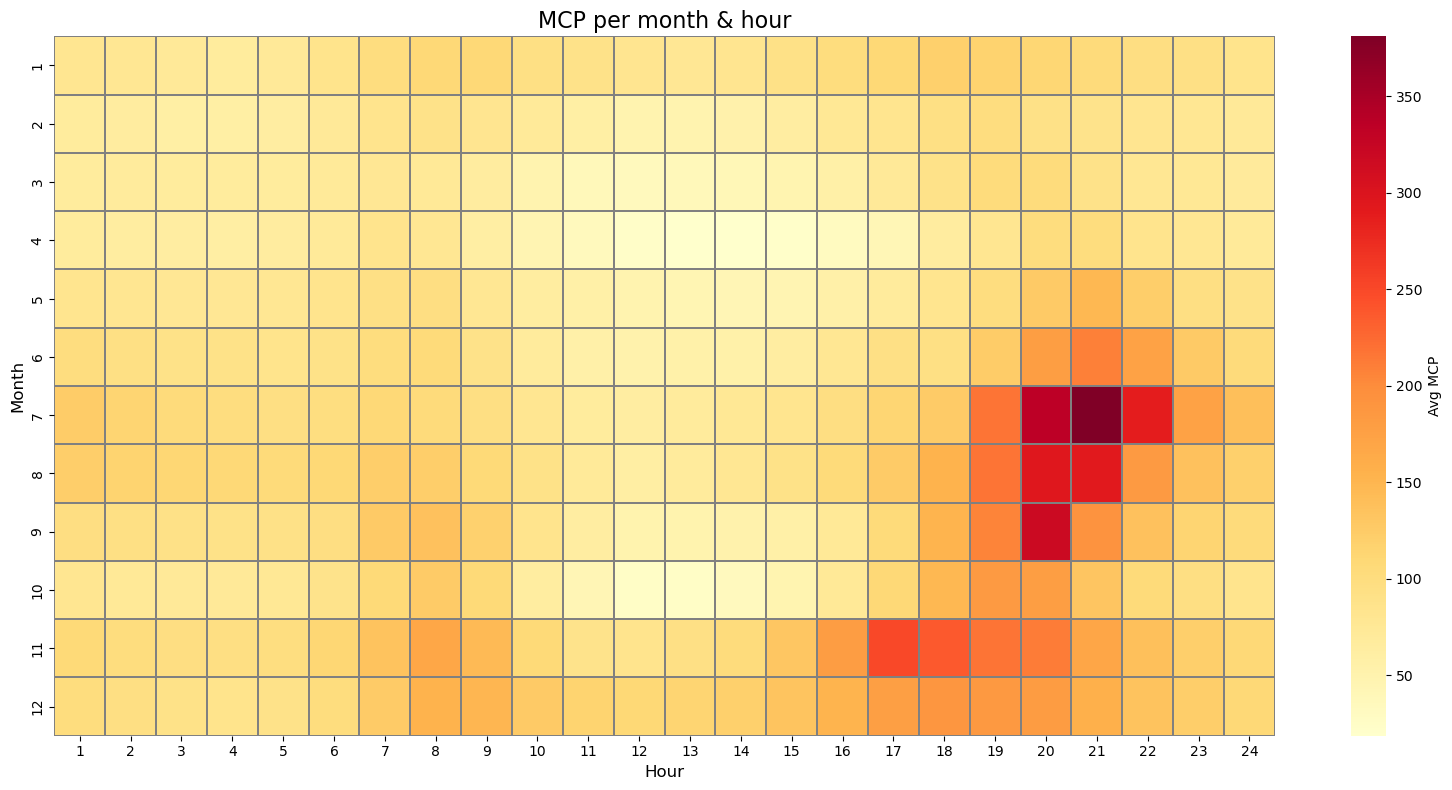

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt


# create h heatmap of Prices per month/hour

plt.figure(figsize=(16, 8))

sns.heatmap(
    pivot_mcp_mean,
    cmap="YlOrRd",      
    linewidths=0.3,
    linecolor="gray",
    annot=False,           
    cbar_kws={"label": "Avg MCP"}
)

plt.title("MCP per month & hour", fontsize=16)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Month", fontsize=12)
plt.tight_layout()
plt.show()

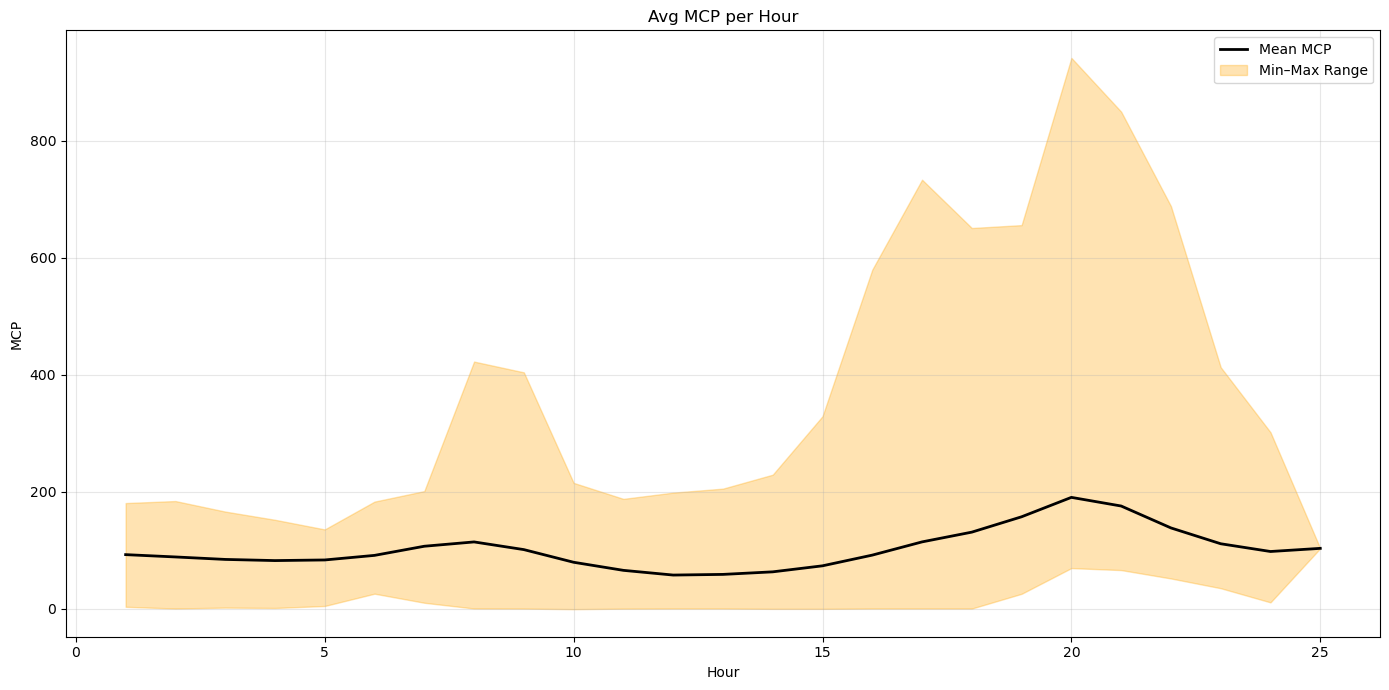

In [34]:
#create a plot for MCP per Hour 

plt.figure(figsize=(14, 7))

plt.plot(mcp_per_hour["HOUR"], mcp_per_hour["mean_mcp"],
         color="black", linewidth=2, label="Mean MCP")

plt.fill_between(
    mcp_per_hour["HOUR"],
    mcp_per_hour["min_mcp"],
    mcp_per_hour["max_mcp"],
    color="orange",
    alpha=0.3,
    label="Min–Max Range"
)

plt.xlabel("Hour")
plt.ylabel("MCP")
plt.title("Avg MCP per Hour")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
data

,TARGET,BIDDING_ZONE_DESCR,SIDE_DESCR,DDAY,ASSET_DESCR,CLASSIFICATION,DELIVERY_MTU,DELIVERY_DURATION,HOUR,MCP,TOTAL_TRADES,PUB_TIME,VER,MONTH
0,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 00:00:00,60,1,107.09,91.0,2023-12-31 14:22:19,1,1
1,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 01:00:00,60,2,104.00,93.0,2023-12-31 14:22:19,1,1
2,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 02:00:00,60,3,100.00,40.0,2023-12-31 14:22:19,1,1
3,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 03:00:00,60,4,85.66,41.0,2023-12-31 14:22:19,1,1
4,DAM,Mainland Greece,Buy,20240101,GR-AL,Exports,2024-01-01 08:00:00,60,9,65.00,9.0,2023-12-31 14:22:19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156495,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 19:00:00,60,20,178.88,75.0,2024-12-30 14:21:04,1,12
156496,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 20:00:00,60,21,164.94,75.0,2024-12-30 14:21:04,1,12
156497,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 21:00:00,60,22,150.00,75.0,2024-12-30 14:21:04,1,12
156498,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 22:00:00,60,23,122.04,75.0,2024-12-30 14:21:04,1,12


In [26]:
#Agg per Side and Class the traded quantities

trades_per_class = data.groupby(["SIDE_DESCR", "CLASSIFICATION"])["TOTAL_TRADES"].agg(sum_trades="sum", avg_trades="mean").reset_index()

In [27]:
trades_per_class

,SIDE_DESCR,CLASSIFICATION,sum_trades,avg_trades
0,Buy,CRETE LOAD,3.353535e+06,381.777646
1,Buy,Exports,7.490024e+06,269.444719
2,Buy,HV,7.117500e+06,810.280108
3,Buy,LOSSES,1.047556e+06,119.257229
4,Buy,LV,3.093842e+07,3522.133541
5,Buy,MV,1.145603e+07,1304.192856
6,Buy,PUMP,1.329409e+05,160.750744
7,Buy,RES,1.994626e+04,7.484525
8,Sell,Big Hydro,2.565712e+06,377.977632
9,Sell,CRETE CONVENTIONAL,1.642764e+06,187.017797


In [28]:
#filtering the buy side

buy_trades_per_class = trades_per_class[trades_per_class['SIDE_DESCR'] == 'Buy']

In [29]:
buy_trades_per_class

,SIDE_DESCR,CLASSIFICATION,sum_trades,avg_trades
0,Buy,CRETE LOAD,3.353535e+06,381.777646
1,Buy,Exports,7.490024e+06,269.444719
2,Buy,HV,7.117500e+06,810.280108
3,Buy,LOSSES,1.047556e+06,119.257229
4,Buy,LV,3.093842e+07,3522.133541
5,Buy,MV,1.145603e+07,1304.192856
6,Buy,PUMP,1.329409e+05,160.750744
7,Buy,RES,1.994626e+04,7.484525


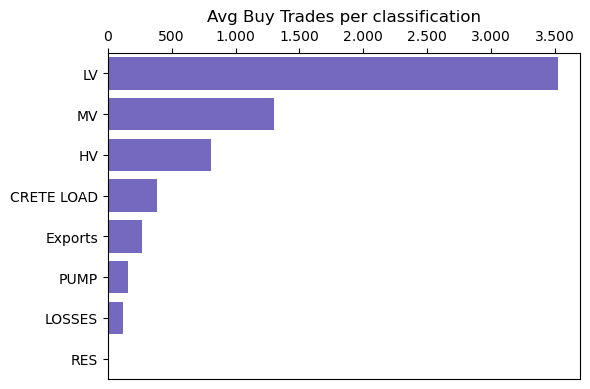

In [37]:
df = buy_trades_per_class.copy()


df = df[["CLASSIFICATION", "avg_trades"]]


df["avg_trades"] = df["avg_trades"].round().astype(int)


df = df.sort_values("avg_trades", ascending=False)

plt.figure(figsize=(6, 4))


ax = sns.barplot(
    data=df,
    y="CLASSIFICATION",
    x="avg_trades",
    color="#6A5ACD"   
)

plt.xlabel("")
plt.ylabel("")


ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title("Avg Buy Trades per classification")
plt.tight_layout()
plt.show()


In [45]:
#filtering the sell side

sell_trades_per_class = trades_per_class[trades_per_class['SIDE_DESCR'] == 'Sell']

In [46]:
sell_trades_per_class

,SIDE_DESCR,CLASSIFICATION,sum_trades,avg_trades
8,Sell,Big Hydro,2.565712e+06,377.977632
9,Sell,CRETE CONVENTIONAL,1.642764e+06,187.017797
10,Sell,CRETE RENEWABLES,7.953015e+05,90.539789
11,Sell,Imports,7.697135e+06,217.962711
12,Sell,Lignite,2.016010e+06,497.534593
13,Sell,Natural Gas,2.186481e+07,2489.162945
14,Sell,RES,2.497422e+07,2843.148802


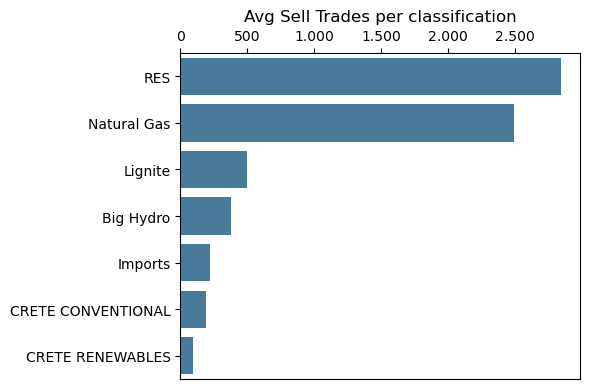

In [47]:
df = sell_trades_per_class.copy()


df = df[["CLASSIFICATION", "avg_trades"]]


df["avg_trades"] = df["avg_trades"].round().astype(int)


df = df.sort_values("avg_trades", ascending=False)

plt.figure(figsize=(6, 4))


ax = sns.barplot(
    data=df,
    y="CLASSIFICATION",
    x="avg_trades",
    color="#3A7FA7"  
)


plt.xlabel("")
plt.ylabel("")


ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title("Avg Sell Trades per classification")
plt.tight_layout()
plt.show()


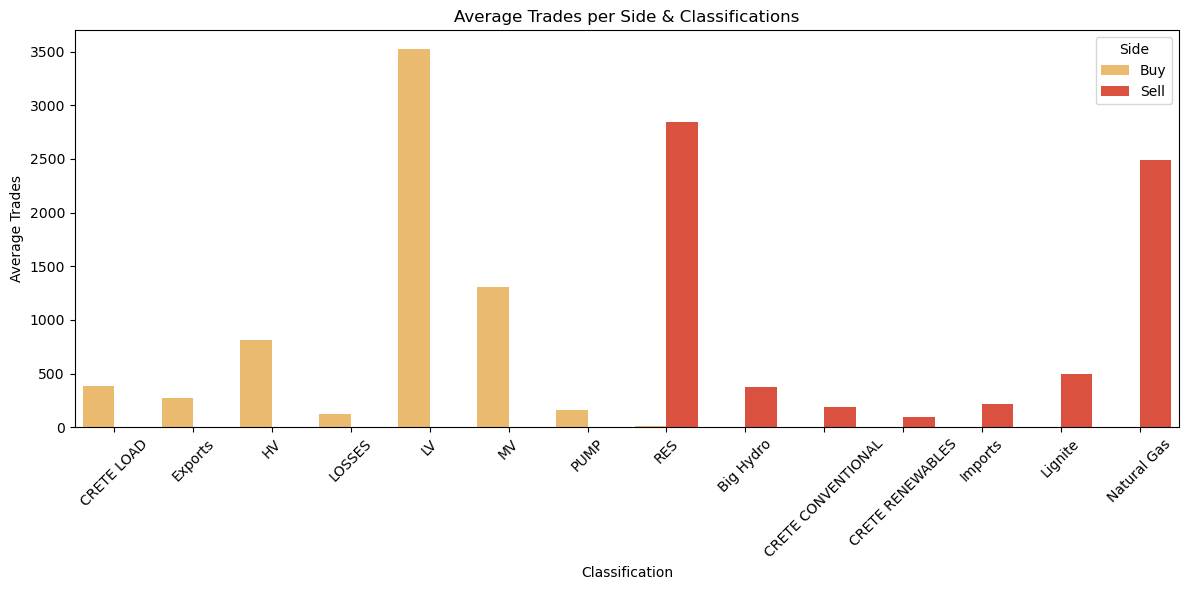

In [50]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=trades_per_class,
    x="CLASSIFICATION",
    y="avg_trades",
    hue="SIDE_DESCR",
    palette="YlOrRd"
)


plt.title("Average Trades per Side & Classifications")
plt.xlabel("Classification")
plt.ylabel("Average Trades")
plt.xticks(rotation=45)
plt.legend(title="Side")
plt.tight_layout()
plt.show()

In [55]:
trades_per_hour_per_class = data.groupby(["HOUR", "CLASSIFICATION"])["TOTAL_TRADES"].mean().reset_index()

In [56]:
trades_per_hour_per_class

,HOUR,CLASSIFICATION,TOTAL_TRADES
0,1,Big Hydro,106.716677
1,1,CRETE CONVENTIONAL,132.200820
2,1,CRETE LOAD,294.324615
3,1,CRETE RENEWABLES,73.333525
4,1,Exports,228.475021
...,...,...,...
333,25,LOSSES,118.500000
334,25,LV,2307.852000
335,25,MV,875.525000
336,25,Natural Gas,2861.834000


In [57]:
mcp_per_hour

,HOUR,mean_mcp,min_mcp,max_mcp,count_trades,std_mcp
0,1,92.252343,3.00,180.47,6521,25.586433
1,2,88.289715,0.04,183.92,6312,23.915332
2,3,84.063199,1.64,165.92,6299,22.866909
3,4,82.084033,0.99,151.87,6291,22.320834
4,5,83.138424,4.40,135.39,6369,20.530947
5,6,90.978021,25.44,182.97,6507,20.429775
6,7,106.608645,9.92,200.94,6546,28.786701
7,8,113.991704,0.10,422.50,6427,47.038205
8,9,100.852544,-0.07,404.09,6474,43.892338
9,10,79.193462,-1.02,215.00,6539,37.026770


In [60]:
data_sells = data[data['SIDE_DESCR'] == 'Sell']

In [61]:
data_sells

,TARGET,BIDDING_ZONE_DESCR,SIDE_DESCR,DDAY,ASSET_DESCR,CLASSIFICATION,DELIVERY_MTU,DELIVERY_DURATION,HOUR,MCP,TOTAL_TRADES,PUB_TIME,VER,MONTH
185,DAM,Mainland Greece,Sell,20240101,AL-GR,Imports,2024-01-01 00:00:00,60,1,107.09,323.0,2023-12-31 14:22:19,1,1
186,DAM,Mainland Greece,Sell,20240101,AL-GR,Imports,2024-01-01 01:00:00,60,2,104.00,348.0,2023-12-31 14:22:19,1,1
187,DAM,Mainland Greece,Sell,20240101,AL-GR,Imports,2024-01-01 02:00:00,60,3,100.00,312.0,2023-12-31 14:22:19,1,1
188,DAM,Mainland Greece,Sell,20240101,AL-GR,Imports,2024-01-01 03:00:00,60,4,85.66,261.0,2023-12-31 14:22:19,1,1
189,DAM,Mainland Greece,Sell,20240101,AL-GR,Imports,2024-01-01 04:00:00,60,5,85.00,312.0,2023-12-31 14:22:19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156495,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 19:00:00,60,20,178.88,75.0,2024-12-30 14:21:04,1,12
156496,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 20:00:00,60,21,164.94,75.0,2024-12-30 14:21:04,1,12
156497,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 21:00:00,60,22,150.00,75.0,2024-12-30 14:21:04,1,12
156498,DAM,Mainland Greece,Sell,20241231,TR-GR,Imports,2024-12-31 22:00:00,60,23,122.04,75.0,2024-12-30 14:21:04,1,12


In [62]:
sells_trades_per_hour_per_class = trades_per_hour_per_class = data_sells.groupby(["HOUR", "CLASSIFICATION"])["TOTAL_TRADES"].mean().reset_index()

In [63]:
sells_trades_per_hour_per_class

,HOUR,CLASSIFICATION,TOTAL_TRADES
0,1,Big Hydro,106.716677
1,1,CRETE CONVENTIONAL,132.200820
2,1,CRETE RENEWABLES,73.333525
3,1,Imports,252.295874
4,1,Lignite,438.239938
...,...,...,...
168,25,CRETE CONVENTIONAL,90.500000
169,25,CRETE RENEWABLES,30.000000
170,25,Imports,358.175000
171,25,Natural Gas,2861.834000


In [64]:
sells_trades_per_hour_per_class1 = sells_trades_per_hour_per_class.iloc[:-1]

In [65]:
sells_trades_per_hour_per_class1

,HOUR,CLASSIFICATION,TOTAL_TRADES
0,1,Big Hydro,106.716677
1,1,CRETE CONVENTIONAL,132.200820
2,1,CRETE RENEWABLES,73.333525
3,1,Imports,252.295874
4,1,Lignite,438.239938
...,...,...,...
167,24,RES,1616.277299
168,25,CRETE CONVENTIONAL,90.500000
169,25,CRETE RENEWABLES,30.000000
170,25,Imports,358.175000


In [66]:
sells_trades_per_hour_per_class1 = sells_trades_per_hour_per_class1[sells_trades_per_hour_per_class1['HOUR'] != 25]

In [67]:
sells_trades_per_hour_per_class1

,HOUR,CLASSIFICATION,TOTAL_TRADES
0,1,Big Hydro,106.716677
1,1,CRETE CONVENTIONAL,132.200820
2,1,CRETE RENEWABLES,73.333525
3,1,Imports,252.295874
4,1,Lignite,438.239938
...,...,...,...
163,24,CRETE RENEWABLES,72.753479
164,24,Imports,230.480673
165,24,Lignite,437.660035
166,24,Natural Gas,2913.566134


In [68]:
sells_trades_prices_perhour = sells_trades_per_hour_per_class1.merge(mcp_per_hour[['HOUR','mean_mcp']], on='HOUR',how='left')

In [69]:
sells_trades_prices_perhour

,HOUR,CLASSIFICATION,TOTAL_TRADES,mean_mcp
0,1,Big Hydro,106.716677,92.252343
1,1,CRETE CONVENTIONAL,132.200820,92.252343
2,1,CRETE RENEWABLES,73.333525,92.252343
3,1,Imports,252.295874,92.252343
4,1,Lignite,438.239938,92.252343
...,...,...,...,...
163,24,CRETE RENEWABLES,72.753479,97.611277
164,24,Imports,230.480673,97.611277
165,24,Lignite,437.660035,97.611277
166,24,Natural Gas,2913.566134,97.611277


In [71]:
pivot_trades = sells_trades_prices_perhour.pivot(
    index="HOUR",
    columns="CLASSIFICATION",
    values="TOTAL_TRADES"
).fillna(0)


In [72]:
pivot_trades

CLASSIFICATION,Big Hydro,CRETE CONVENTIONAL,CRETE RENEWABLES,Imports,Lignite,Natural Gas,RES
HOUR,,,,,,,
1,106.716677,132.200820,73.333525,252.295874,438.239938,2581.592306,1620.342872
2,88.174452,121.281421,73.574781,293.386218,411.372713,2301.661863,1647.507107
3,80.587540,116.428962,73.948251,298.526128,402.925654,2152.570907,1656.327169
4,74.305344,114.500000,74.353989,298.805809,402.038710,2089.698484,1664.978710
5,139.444444,115.848361,74.681831,293.726703,402.375305,2093.847658,1673.852582
6,159.503729,129.491803,74.831148,272.044813,416.136484,2324.883527,1696.588568
7,258.996743,169.255519,77.271257,242.061810,496.603412,2639.028311,1887.058615
8,293.745674,198.524617,87.251066,211.248848,560.271714,2612.859172,2645.627328
9,202.046859,213.340656,102.517268,177.879199,545.183981,2354.775361,3741.944921


In [74]:
mcp_hour = sells_trades_prices_perhour.groupby("HOUR")["mean_mcp"].first()

In [75]:
keep_cols = ["Big Hydro", "Imports", "Lignite", "Natural Gas", "RES"]

pivot_filtered = pivot_trades[keep_cols]

In [76]:
pivot_filtered

CLASSIFICATION,Big Hydro,Imports,Lignite,Natural Gas,RES
HOUR,,,,,
1,106.716677,252.295874,438.239938,2581.592306,1620.342872
2,88.174452,293.386218,411.372713,2301.661863,1647.507107
3,80.587540,298.526128,402.925654,2152.570907,1656.327169
4,74.305344,298.805809,402.038710,2089.698484,1664.978710
5,139.444444,293.726703,402.375305,2093.847658,1673.852582
6,159.503729,272.044813,416.136484,2324.883527,1696.588568
7,258.996743,242.061810,496.603412,2639.028311,1887.058615
8,293.745674,211.248848,560.271714,2612.859172,2645.627328
9,202.046859,177.879199,545.183981,2354.775361,3741.944921


In [78]:
custom_colors = {
    "Big Hydro": "#4C72B0",      # ψυχρό μπλε
    "Imports": "#8DA0CB",        # απαλό μπλε-γκρι
    "Lignite": "#7570B3",        # muted μωβ
    "Natural Gas": "#6A3D9A",    # πιο σκούρο μωβ
    "RES": "#2ECC71"             # 💚 καθαρό, επαγγελματικό πράσινο
}


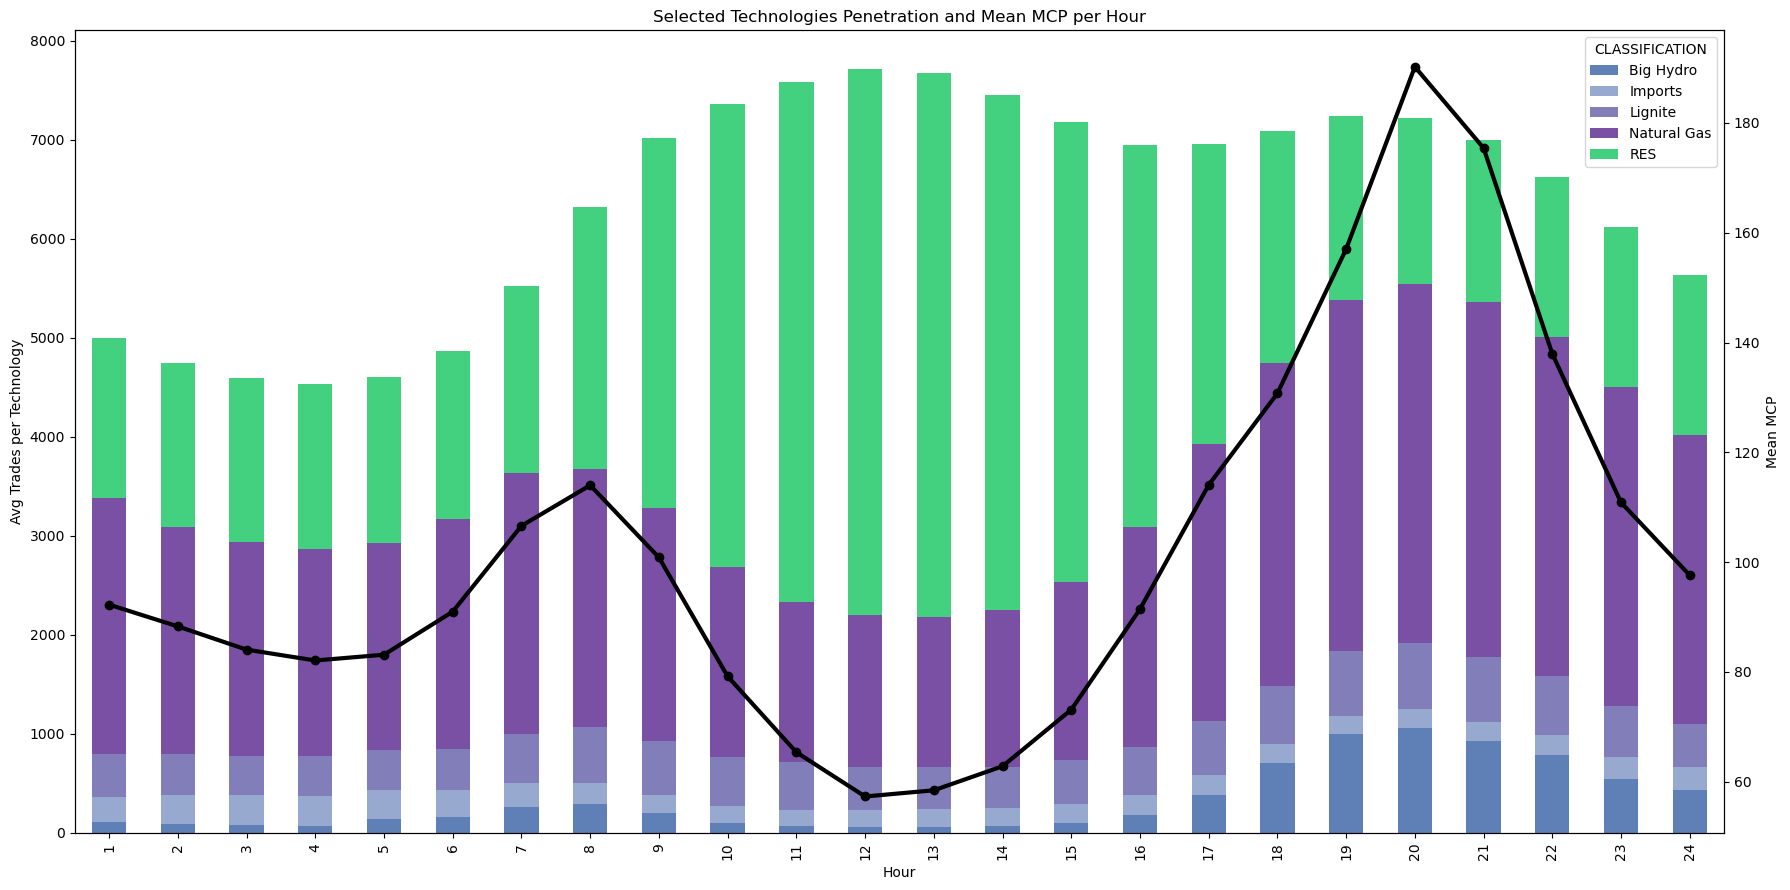

In [79]:
fig, ax1 = plt.subplots(figsize=(18, 9))

pivot_filtered.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=[custom_colors[col] for col in pivot_filtered.columns],
    alpha=0.9
)

ax1.set_xlabel("Hour")
ax1.set_ylabel("Avg Trades per Technology")
ax1.set_title("Selected Technologies Penetration and Mean MCP per Hour")

# MCP line (shifted left)
ax2 = ax1.twinx()
ax2.plot(
    mcp_hour.index - 1,
    mcp_hour.values,
    color="black",
    linewidth=3,
    marker="o"
)

ax2.set_ylabel("Mean MCP")

plt.tight_layout()
plt.show()
